# Customer Churn Predictor

#### What is churn? → When a customer stops using a service.

#### Why important? → Companies want to retain customers = cheaper than acquiring new ones.

#### Use cases: telecom, banking, e-commerce, OTT platforms, SaaS products.

---

#### Importing all necessary libraries

In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math

In [17]:
data = pd.read_csv('E_Comm.csv')

In [18]:
data.sample(5)

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
1090,51091,0,8.0,Computer,1,8.0,Credit Card,Male,3.0,4,Mobile Phone,1,Single,1,1,14.0,1.0,1.0,4.0,149.30
2598,52599,0,6.0,Computer,3,8.0,E wallet,Female,3.0,3,Laptop & Accessory,4,Single,9,0,15.0,1.0,1.0,7.0,151.47
800,50801,0,15.0,Phone,1,NaN,CC,Female,3.0,1,Laptop & Accessory,4,Divorced,7,1,16.0,0.0,1.0,0.0,123.72
2288,52289,0,19.0,Phone,2,7.0,Debit Card,Female,2.0,3,Mobile,5,Single,7,0,12.0,2.0,5.0,7.0,134.23
4144,54145,0,19.0,Mobile Phone,3,27.0,Debit Card,Female,3.0,4,Laptop & Accessory,3,Single,10,0,16.0,2.0,2.0,2.0,173.50


In [19]:
print('Total customers in data :' , data.shape[0])

Total customers in data : 5630


#### Checking null values in any columns

In [20]:
idx = 1
for i in data.columns:
    print(idx,'.',data[i].isna().value_counts())
    idx +=1

1 . CustomerID
False    5630
Name: count, dtype: int64
2 . Churn
False    5630
Name: count, dtype: int64
3 . Tenure
False    5366
True      264
Name: count, dtype: int64
4 . PreferredLoginDevice
False    5630
Name: count, dtype: int64
5 . CityTier
False    5630
Name: count, dtype: int64
6 . WarehouseToHome
False    5379
True      251
Name: count, dtype: int64
7 . PreferredPaymentMode
False    5630
Name: count, dtype: int64
8 . Gender
False    5630
Name: count, dtype: int64
9 . HourSpendOnApp
False    5375
True      255
Name: count, dtype: int64
10 . NumberOfDeviceRegistered
False    5630
Name: count, dtype: int64
11 . PreferedOrderCat
False    5630
Name: count, dtype: int64
12 . SatisfactionScore
False    5630
Name: count, dtype: int64
13 . MaritalStatus
False    5630
Name: count, dtype: int64
14 . NumberOfAddress
False    5630
Name: count, dtype: int64
15 . Complain
False    5630
Name: count, dtype: int64
16 . OrderAmountHikeFromlastYear
False    5365
True      265
Name: count, dtype:

##### We have NULL values in coloumns Tenure, WarehouseToHome, HourSpendOnApp, OrderAmountHikeFromlastYear, CouponUsed, OrderCount, DaySinceLastOrder

In [21]:
cols_zero = ['Tenure', 'HourSpendOnApp', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'DaySinceLastOrder']
cols_median = ['WarehouseToHome', 'OrderCount']

# Fill with 0
data[cols_zero] = data[cols_zero].fillna(0)

# Fill with median
data[cols_median] = data[cols_median].fillna(data[cols_median].median())


##### Now there is not any missing value in any of these columns

#### Checking data types

In [22]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5630 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5630 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5630 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

In [23]:
data.describe()

,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000
mean,52815.500000,0.168384,9.712078,1.654707,15.566785,2.798757,3.688988,3.066785,4.214032,0.284902,14.968561,1.671403,2.961812,4.295737,177.223030
std,1625.385339,0.374240,8.627486,0.915389,8.345961,0.932334,1.023999,1.380194,2.583586,0.451408,4.893091,1.886648,2.879248,3.700134,49.207036
min,50001.000000,0.000000,0.000000,1.000000,5.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,51408.250000,0.000000,1.000000,1.000000,9.000000,2.000000,3.000000,2.000000,2.000000,0.000000,13.000000,1.000000,1.000000,1.000000,145.770000
50%,52815.500000,0.000000,8.000000,1.000000,14.000000,3.000000,4.000000,3.000000,3.000000,0.000000,14.000000,1.000000,2.000000,3.000000,163.280000
75%,54222.750000,0.000000,15.000000,3.000000,20.000000,3.000000,4.000000,4.000000,6.000000,1.000000,18.000000,2.000000,3.000000,7.000000,196.392500
max,55630.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,26.000000,16.000000,16.000000,46.000000,324.990000


In [24]:
data['PreferredPaymentMode'].unique()

array(['Debit Card', 'UPI', 'CC', 'Cash on Delivery', 'E wallet', 'COD',
       'Credit Card'], dtype=object)

In [25]:
#PreferredPaymentMode
c1 = {
    'Debit Card': 'card',
    'Credit Card': 'card',
    'CC': 'card',
    'Cash on Delivery': 'COD',
    'COD': 'COD',
    'UPI': 'UPI',
    'E wallet': 'UPI'
}
#PreferredLoginDevice
c2 = {
    'Mobile Phone': 'Phone',
    'Phone': 'Phone',
}
#PreferredOrderCat
c3 = {
    'Mobile Phone': 'Phone',
    'Mobile': 'Phone',
}

data['PreferredPaymentMode'] = data['PreferredPaymentMode'].replace(c1)
data['PreferredLoginDevice'] = data['PreferredLoginDevice'].replace(c2)
data['PreferedOrderCat'] = data['PreferedOrderCat'].replace(c3)

In [26]:
data['PreferredPaymentMode'].unique()

array(['card', 'UPI', 'COD'], dtype=object)

---

### Univariate Analysis

In [27]:
cat_cols = data.select_dtypes(include=['object']).columns
num_cols = data.select_dtypes(include=['int64','float64']).columns

cat_cols, num_cols

(Index(['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender',
        'PreferedOrderCat', 'MaritalStatus'],
       dtype='object'),
 Index(['CustomerID', 'Churn', 'Tenure', 'CityTier', 'WarehouseToHome',
        'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore',
        'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear',
        'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount'],
       dtype='object'))

In [28]:
print('The mathematical standards for numerical columns are as follows :')
data[num_cols].describe()

The mathematical standards for numerical columns are as follows :


,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000
mean,52815.500000,0.168384,9.712078,1.654707,15.566785,2.798757,3.688988,3.066785,4.214032,0.284902,14.968561,1.671403,2.961812,4.295737,177.223030
std,1625.385339,0.374240,8.627486,0.915389,8.345961,0.932334,1.023999,1.380194,2.583586,0.451408,4.893091,1.886648,2.879248,3.700134,49.207036
min,50001.000000,0.000000,0.000000,1.000000,5.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,51408.250000,0.000000,1.000000,1.000000,9.000000,2.000000,3.000000,2.000000,2.000000,0.000000,13.000000,1.000000,1.000000,1.000000,145.770000
50%,52815.500000,0.000000,8.000000,1.000000,14.000000,3.000000,4.000000,3.000000,3.000000,0.000000,14.000000,1.000000,2.000000,3.000000,163.280000
75%,54222.750000,0.000000,15.000000,3.000000,20.000000,3.000000,4.000000,4.000000,6.000000,1.000000,18.000000,2.000000,3.000000,7.000000,196.392500
max,55630.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,26.000000,16.000000,16.000000,46.000000,324.990000


##### For Categorical columns

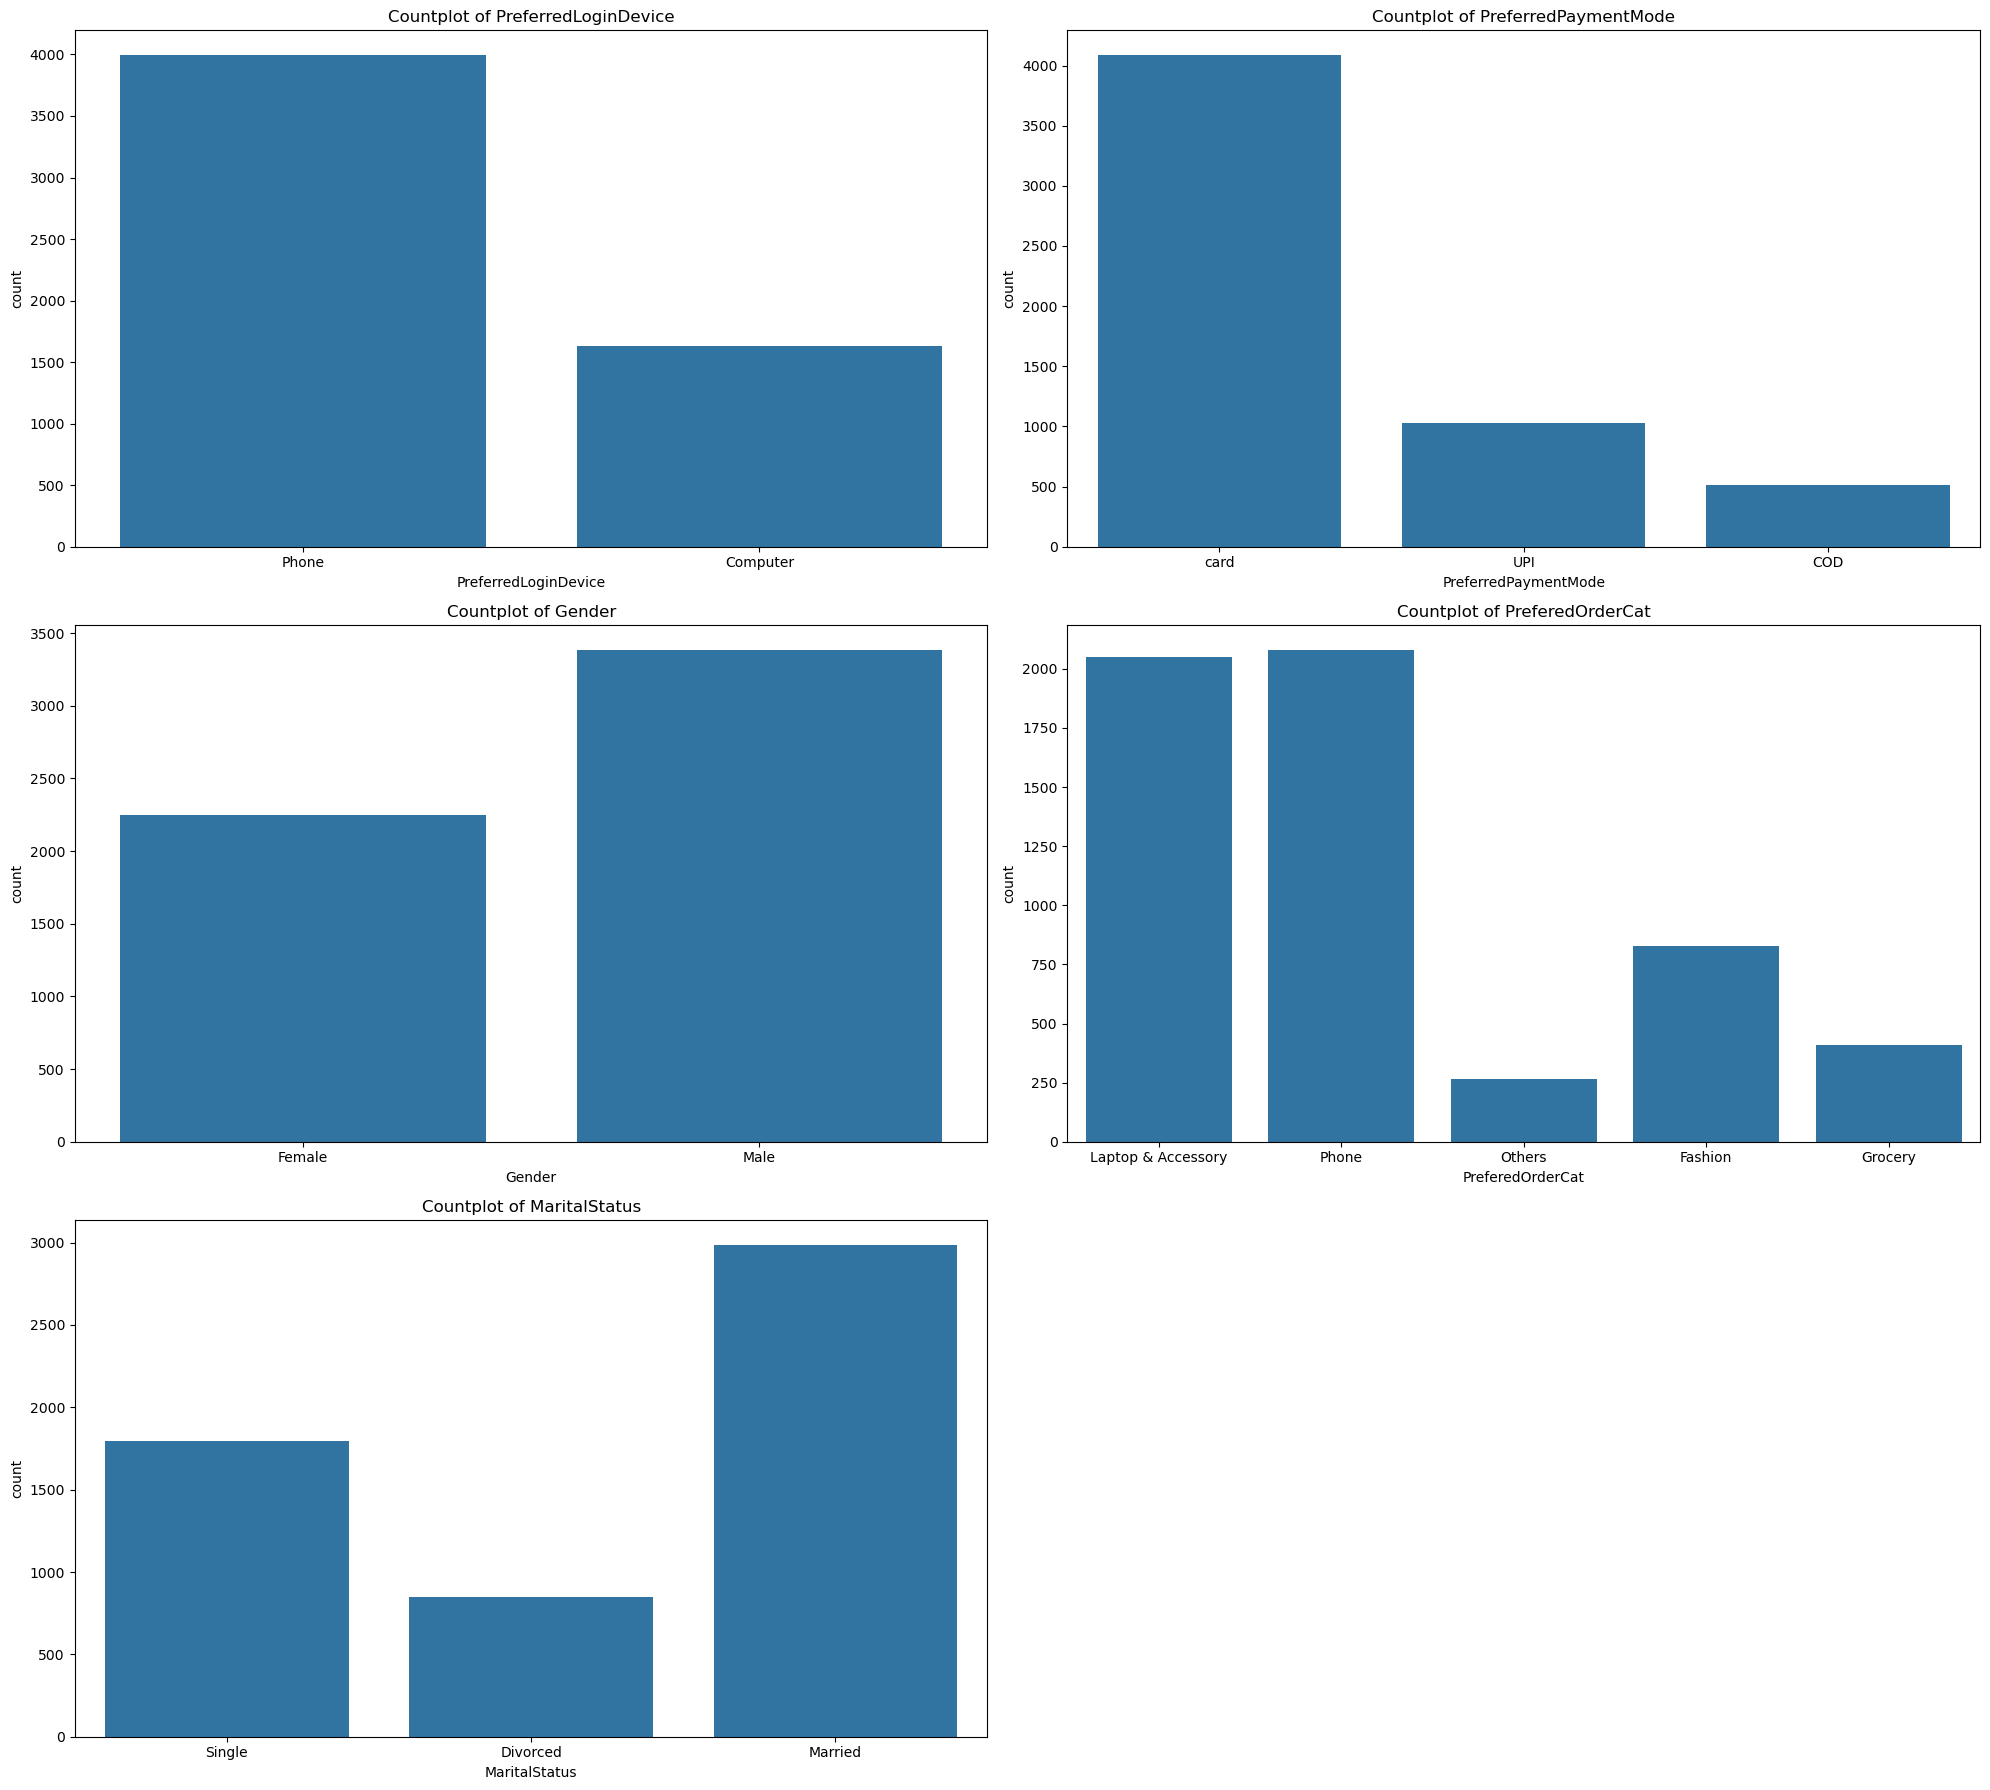

In [337]:
# number of categorical columns
n = len(cat_cols)

# create subplot grid
rows = math.ceil(n / 2)   # 2 columns layout
cols = 2

plt.figure(figsize=(20, 6 * rows))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(rows, cols, i)
    sns.countplot(data=data, x=col)
    plt.title(f"Countplot of {col}")
    if (col == 'state'):
        plt.xticks(rotation =90)
    plt.tight_layout()

plt.show()

##### By this data we can clearly see that :
1. Mobile Phone users are most common in this dataset <br>
2. Number of male users are more then female users which means policies should be made with more focus on males <br>
3. Married Users are more in number on whole website user base <br>
4. Laptops and Accessory are mostly ordered from this E-commerce website <br>
5. Orders are placed mostly from Cards which means offers and vouchers can be increased on online payment modes

##### For Numerical columns

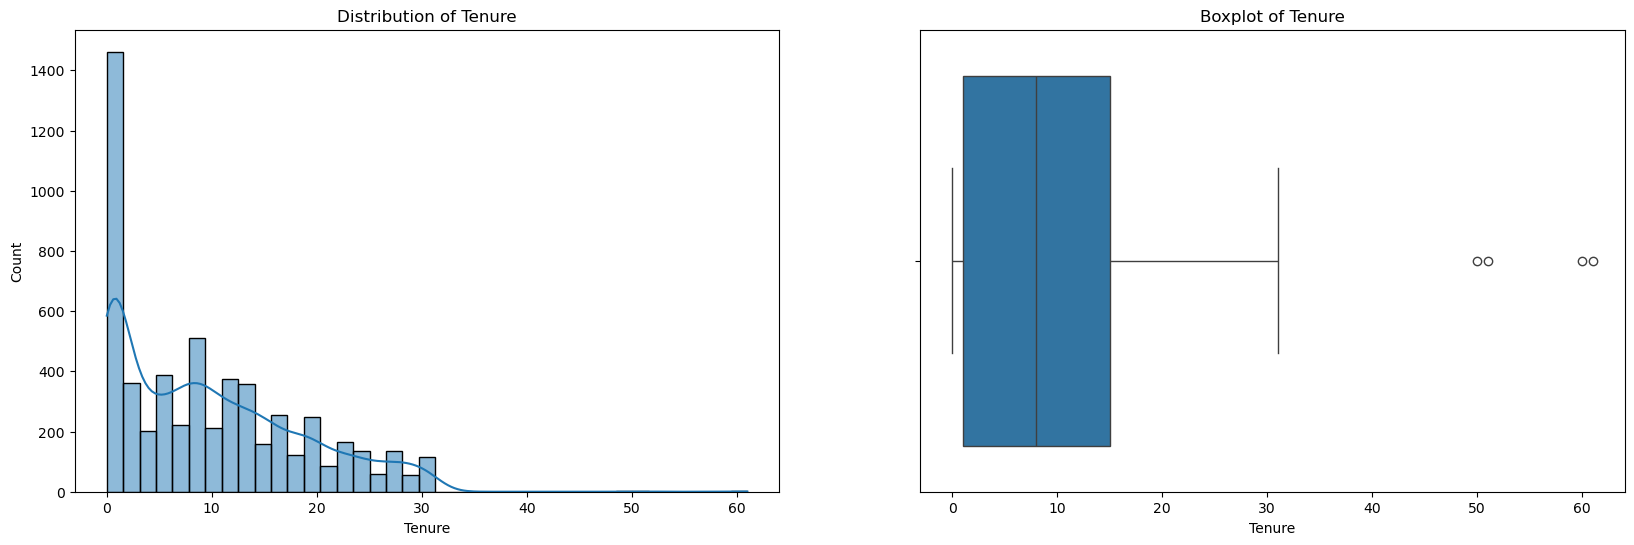

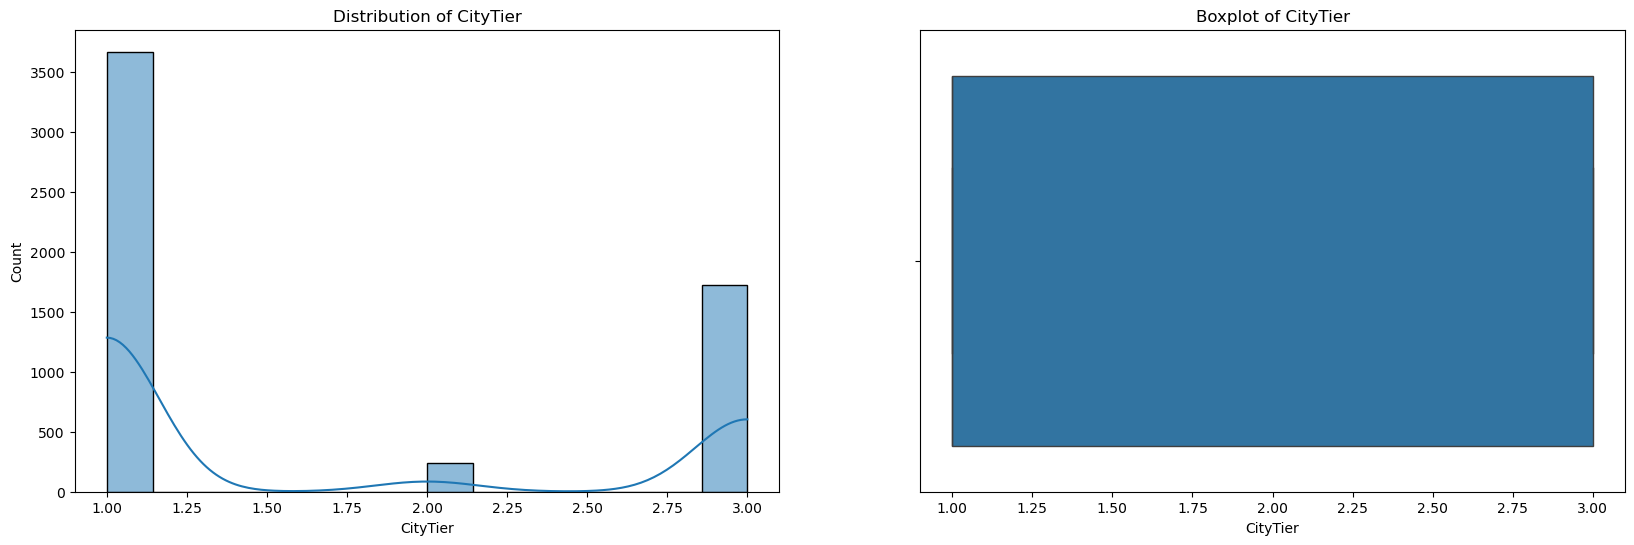

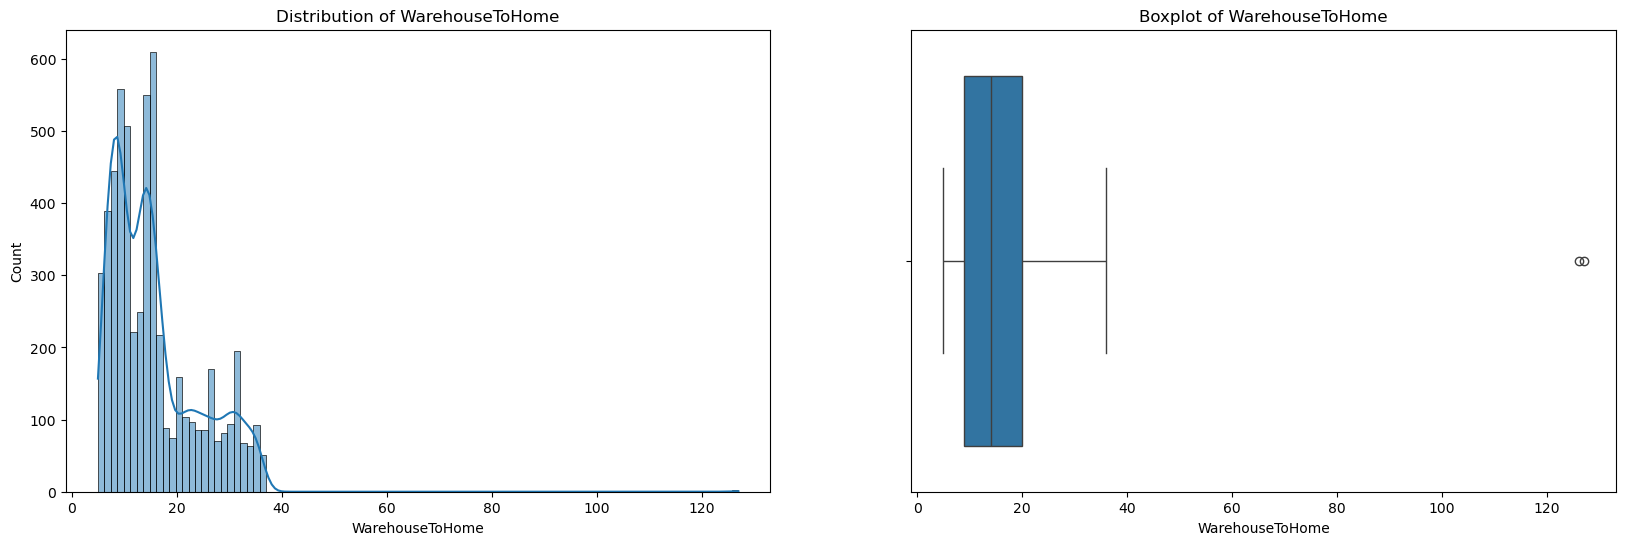

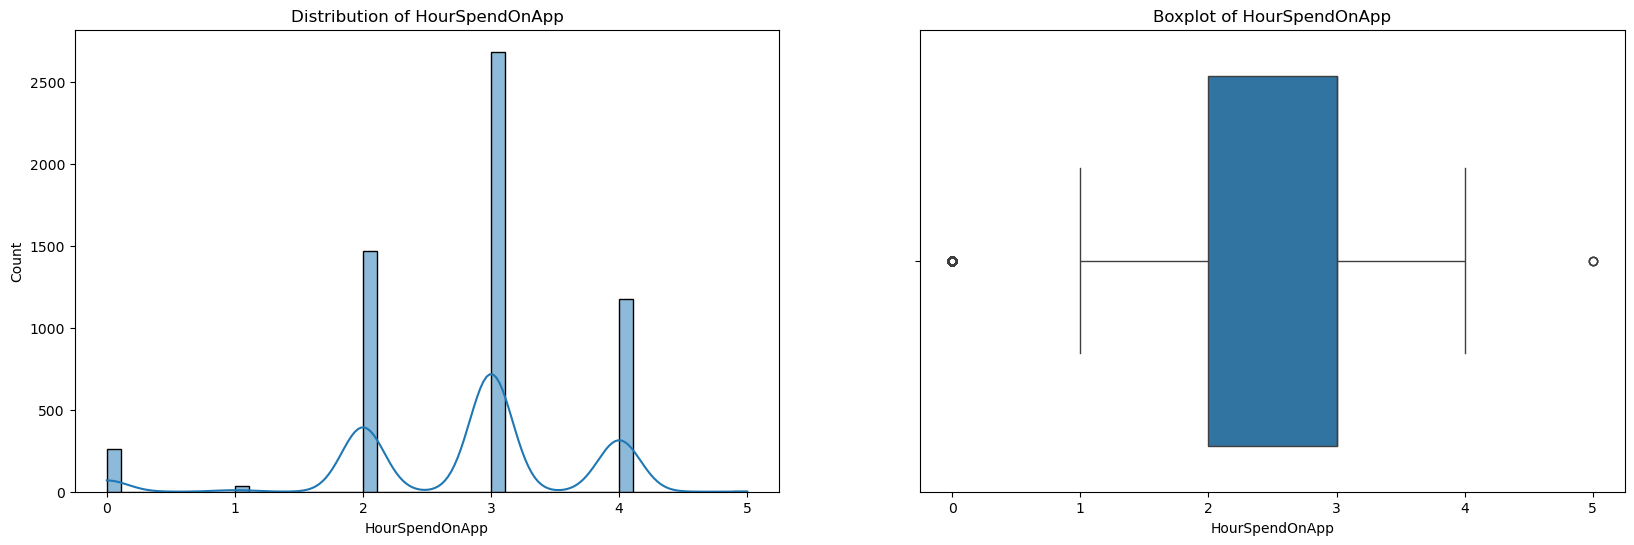

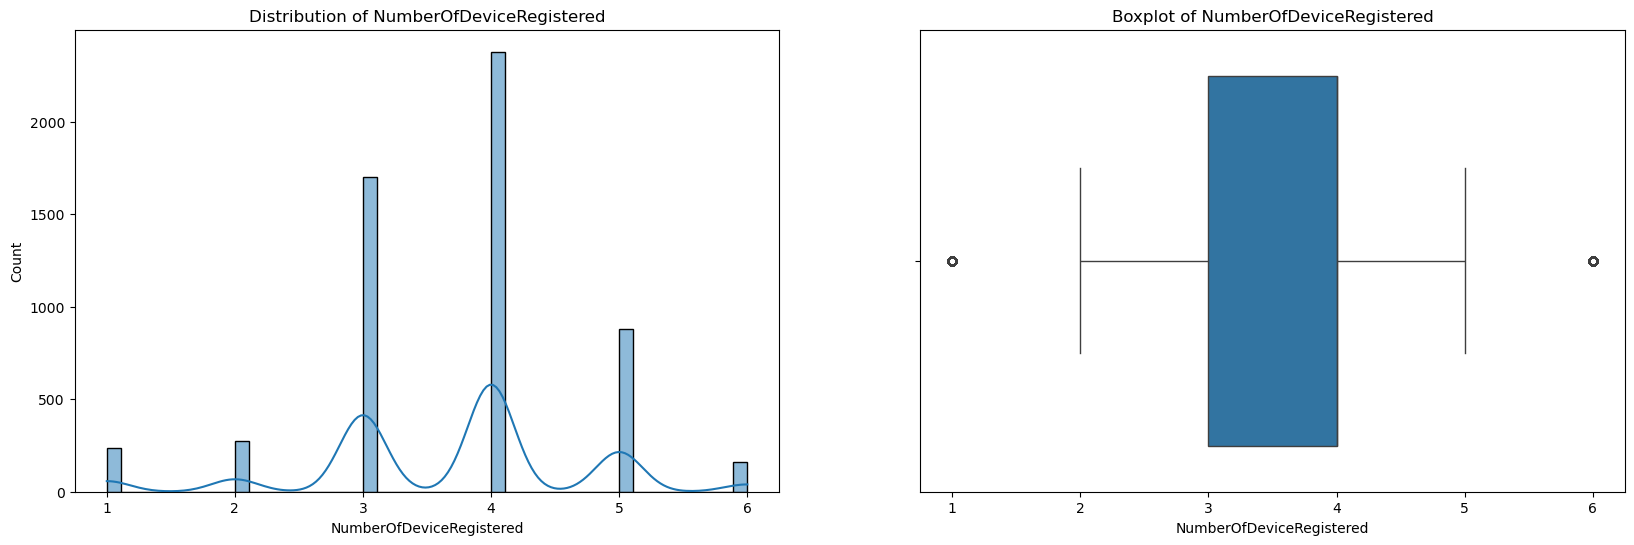

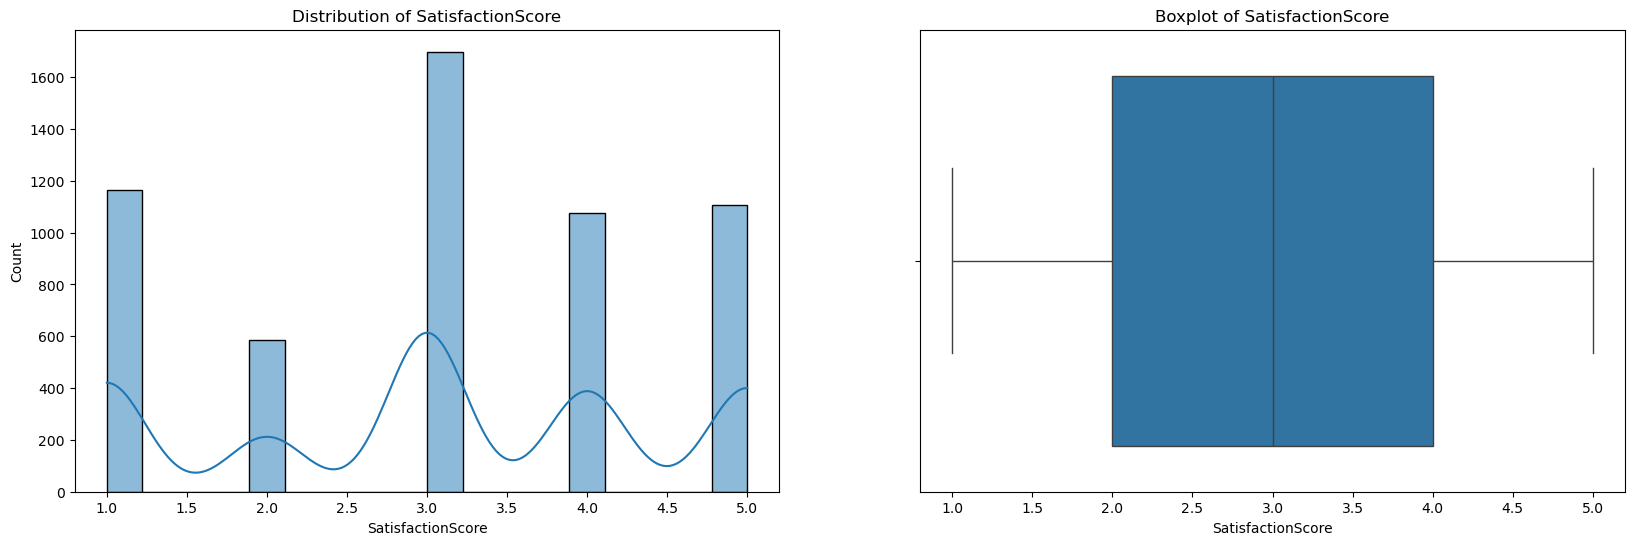

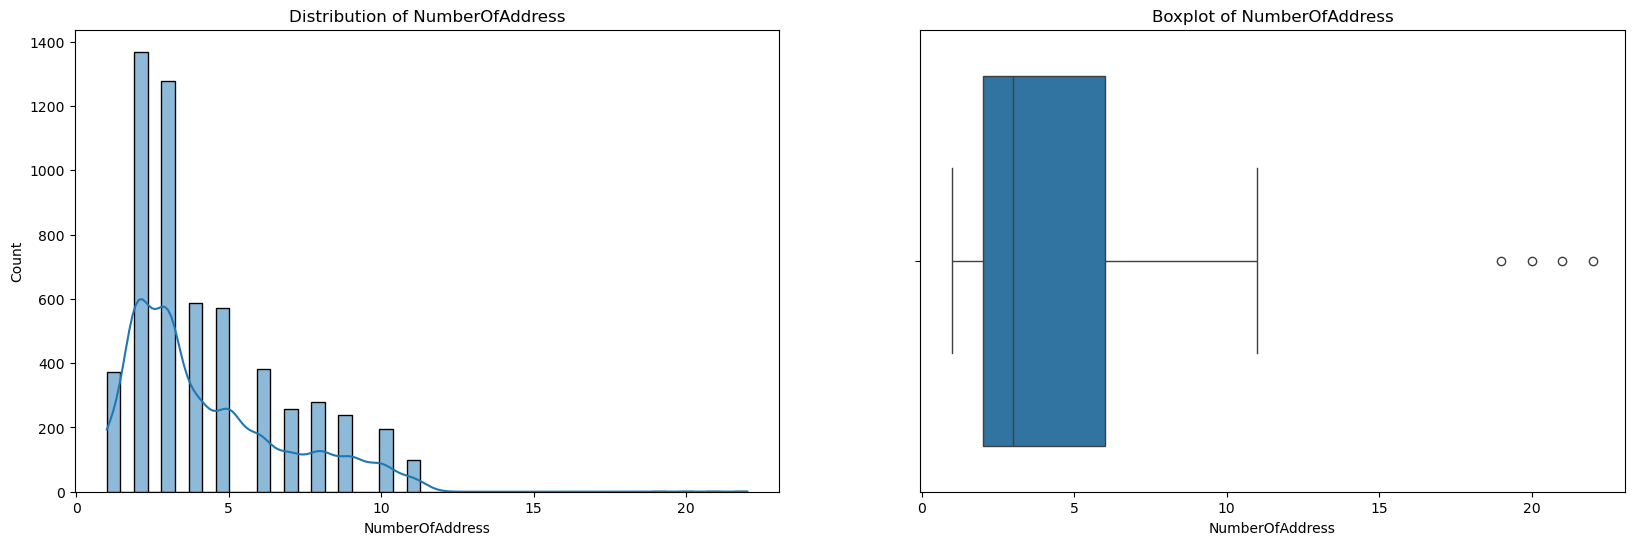

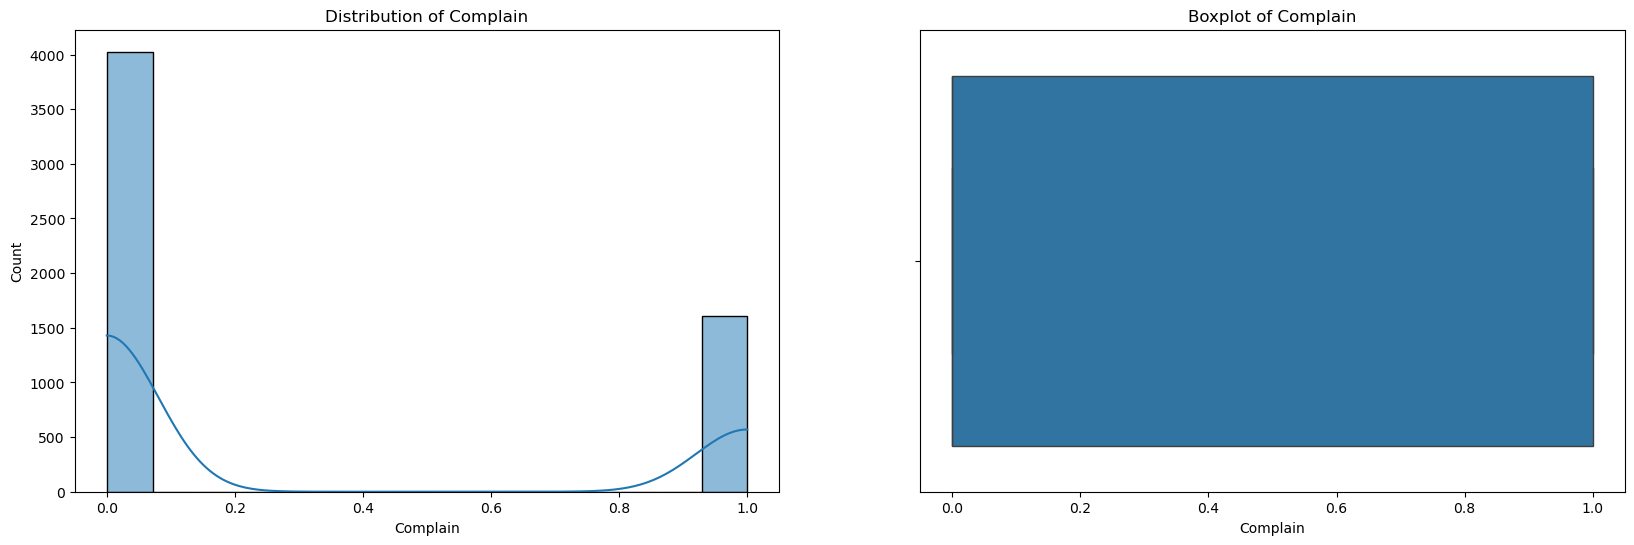

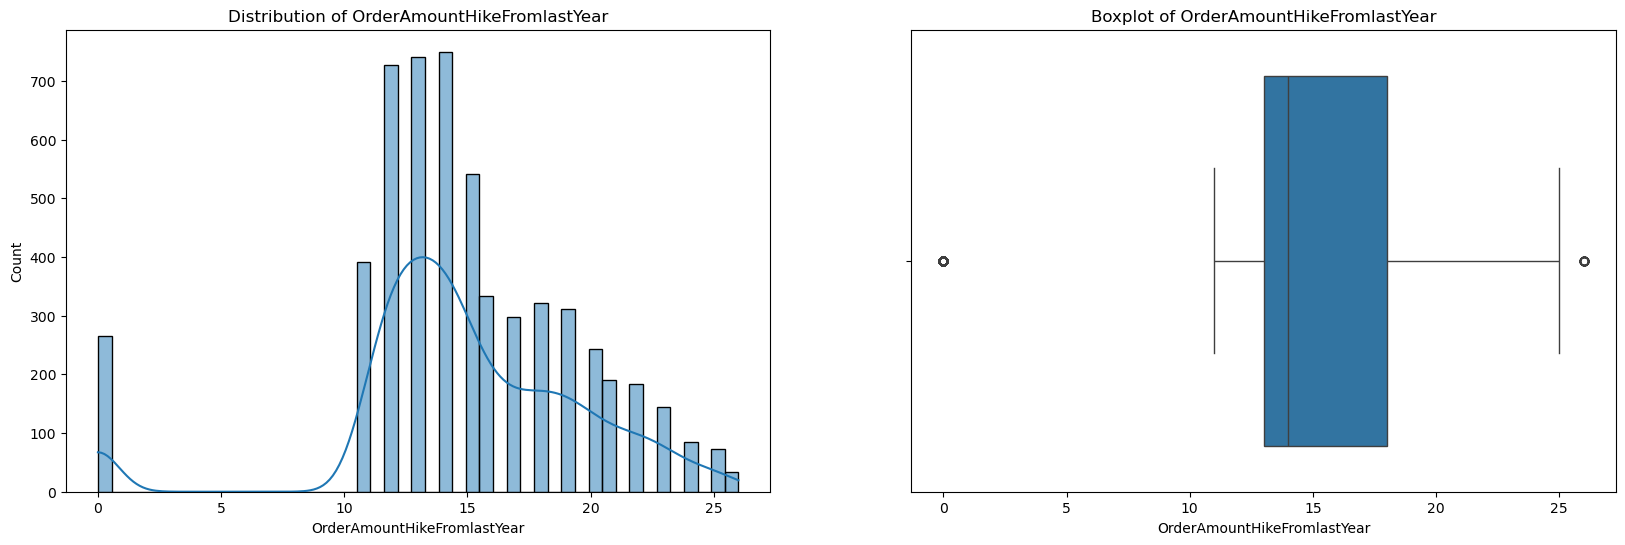

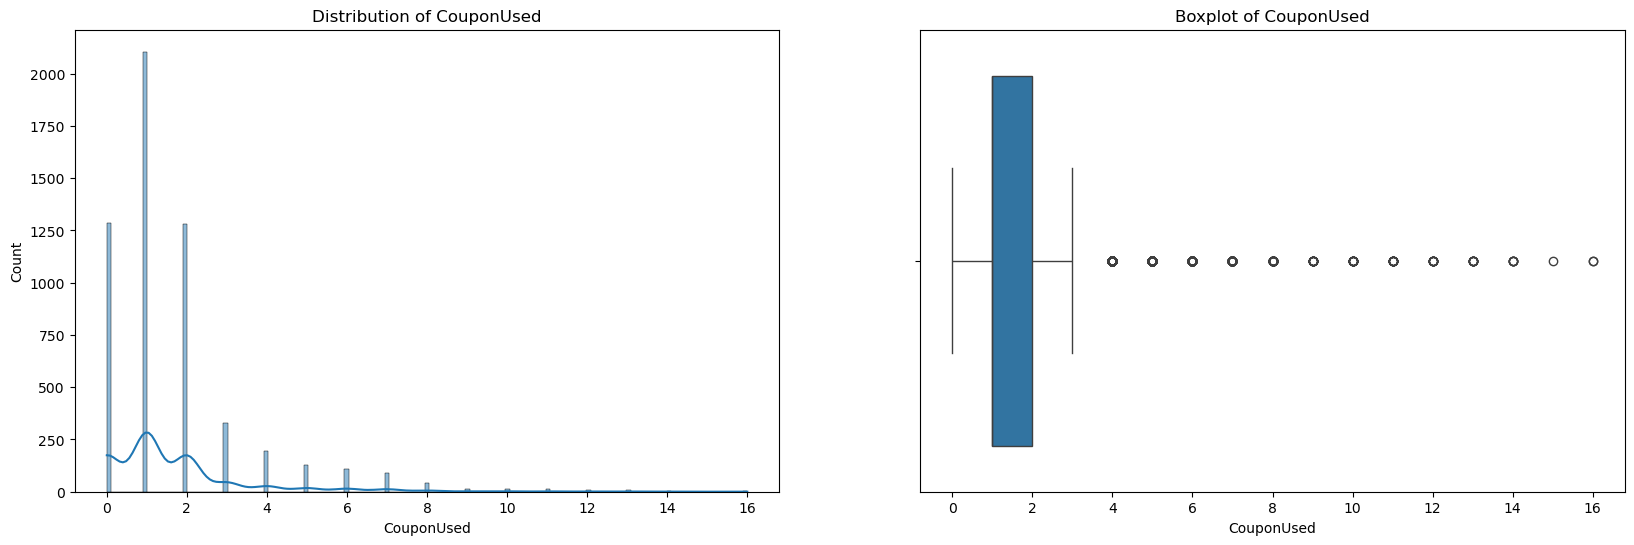

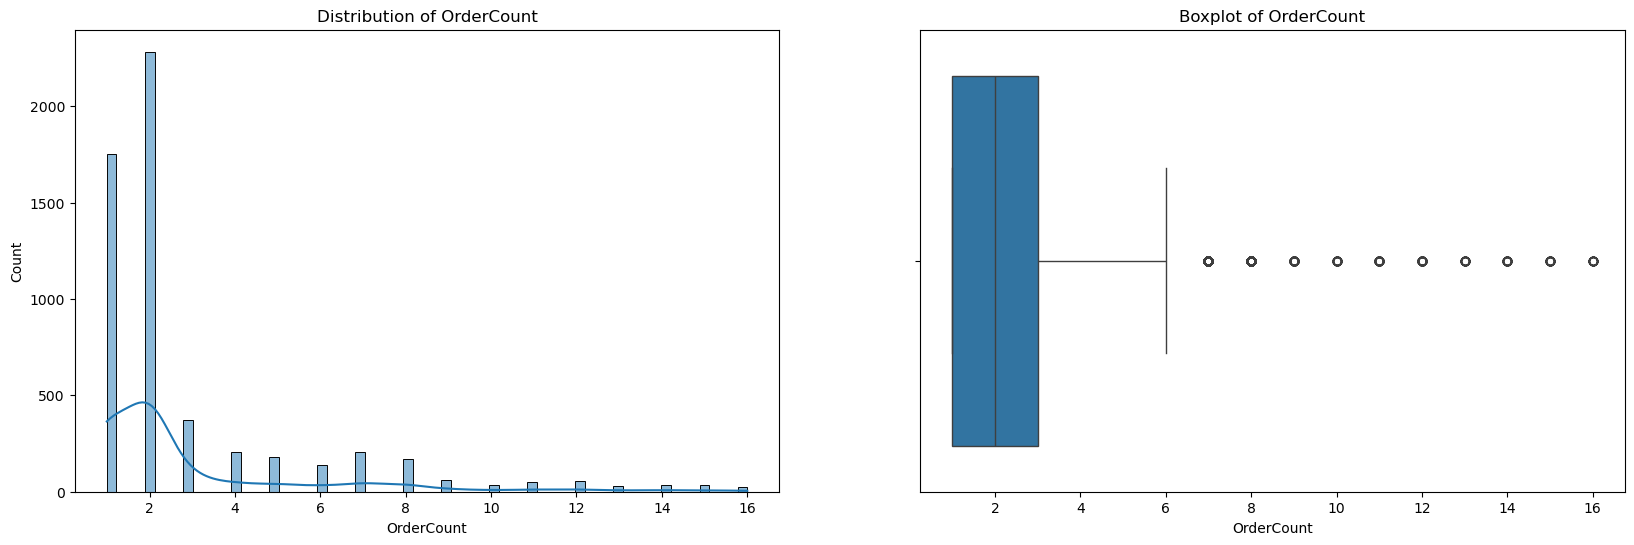

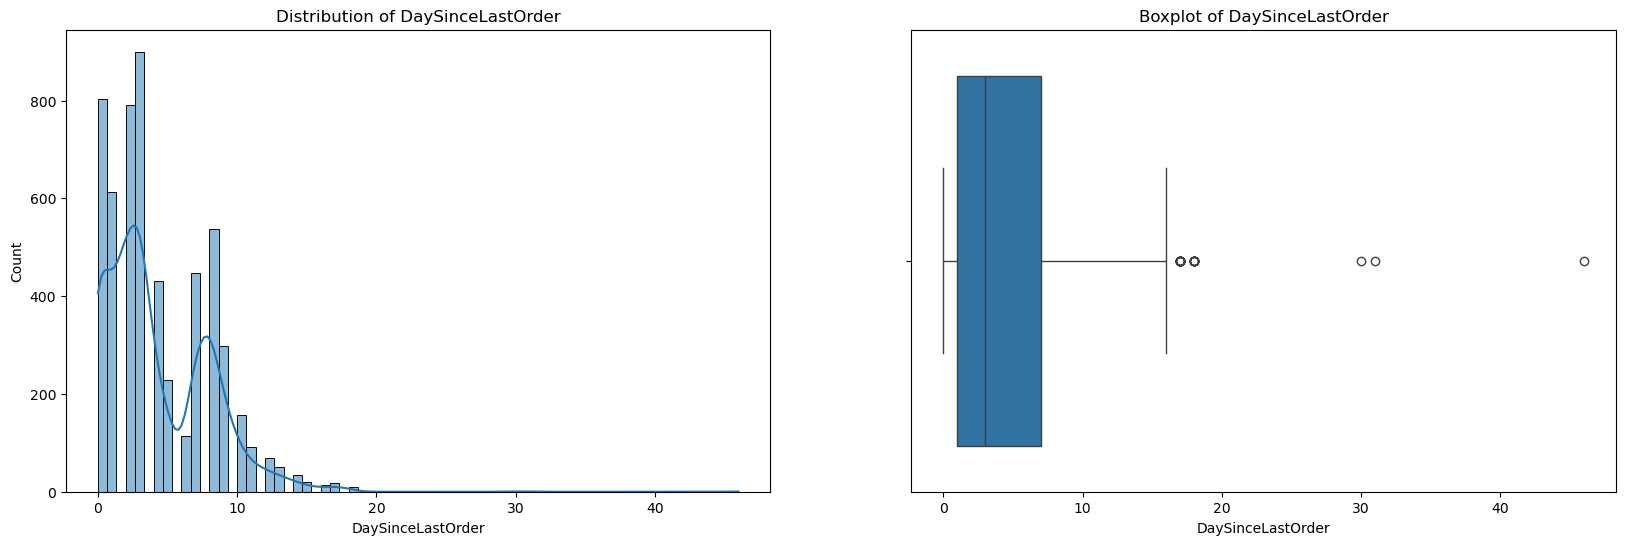

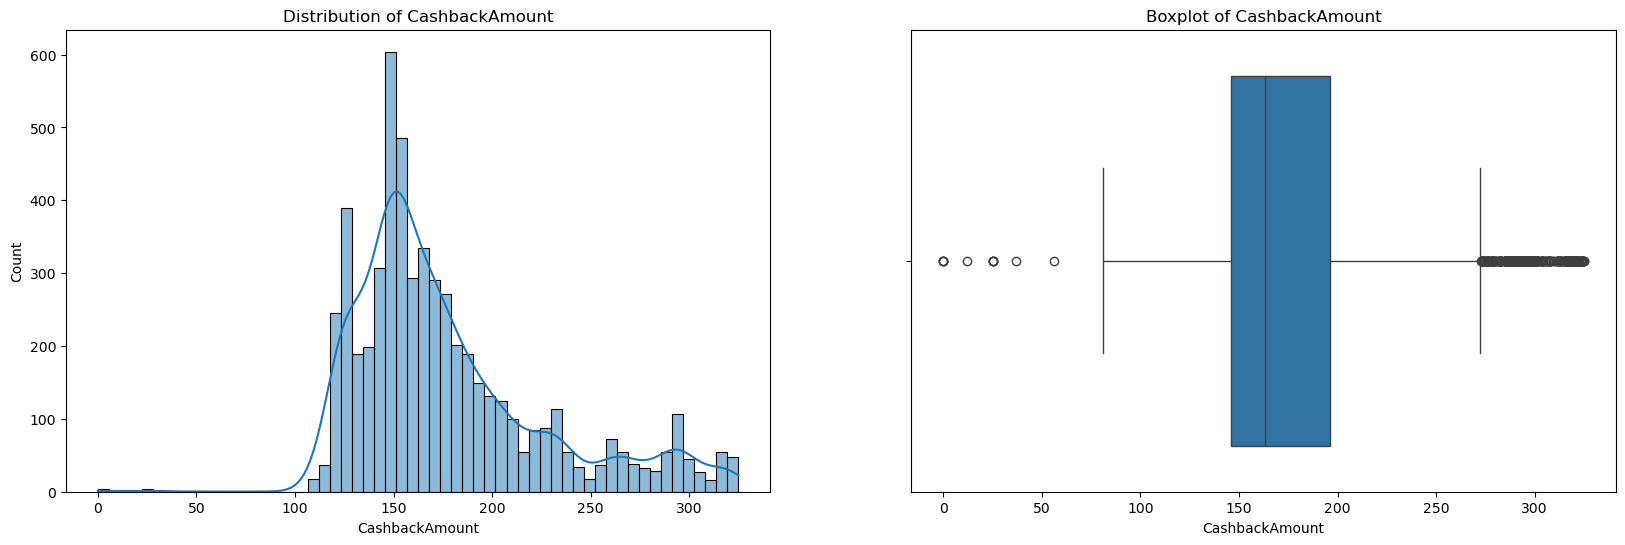

In [222]:
skip_cols = ['CustomerID', 'Churn']

for col in num_cols:
    if col in skip_cols:
        continue
        
    plt.figure(figsize=(20,6))
    
    plt.subplot(1,2,1)
    sns.histplot(data[col], kde=True)
    plt.title(f"Distribution of {col}")
    if (col =='date_of_registration'):
        plt.xticks(rotation = 90)
    
    plt.subplot(1,2,2)
    sns.boxplot(x=data[col])
    plt.title(f"Boxplot of {col}")
    if (col =='date_of_registration'):
        plt.xticks(rotation = 90)
    
    plt.show()


#### Tenure
##### - Most of the customers leave in 1-5 months. Some outliers are present in this column i.e. > 45 years
#### CityTier
##### - Tier 1 city customers are more then the other two types, which means Tier 2/3 do not have facilties provided by the platform
##### - Tier 2 city have less customers than Tier 3 which is very odd
#### Warehouse To Home
##### - Maximum 40 kms is the limit for delivery except the outliers
#### HourSpendOnApp
##### - 0 and 1 hours are very less. 2/3/4 hours are very often which is good
#### NumberOfDeviceRegistered
##### - Maximum users have 3 to 5 devices registered which means users usually login with different devices. Some outliers are also present in this
#### SatisfactionScore
##### - Median of score is 3.0
##### - 1.0 and 2.0 score covers quiet good percentage which means users are not happy with platform
#### Complain Raised last month
##### - 27.2% complaints are registered which is big number. Improvement in Customer Support is needed
#### OrderAmount Hike
##### - Almost normally distributed and quiet left skewed which is good for growth
#### Coupon Used
##### - Left Skewed which means coupons are not used per number of coupons generated
#### Order Count
##### - Median of OrderCount is approx 2 which means users are not ordering in bulk. Some of them are exceptions which are oredering 16 items too
#### DaySince LastOrder
##### - It is LEFT SKEWED which is a good sign that customers are returning on website after using it
#### CashbackAmt
##### - It is normally distributed and its median is almost 170 which can be used to reduce the capital burns of company

---

### Bivariate Analysis

Categorical Cols : ['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender',
        'PreferedOrderCat', 'MaritalStatus'] <br>
Numerical Cols : ['CustomerID', 'Churn', 'Tenure', 'CityTier', 'WarehouseToHome',
        'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore',
        'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear',
        'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']

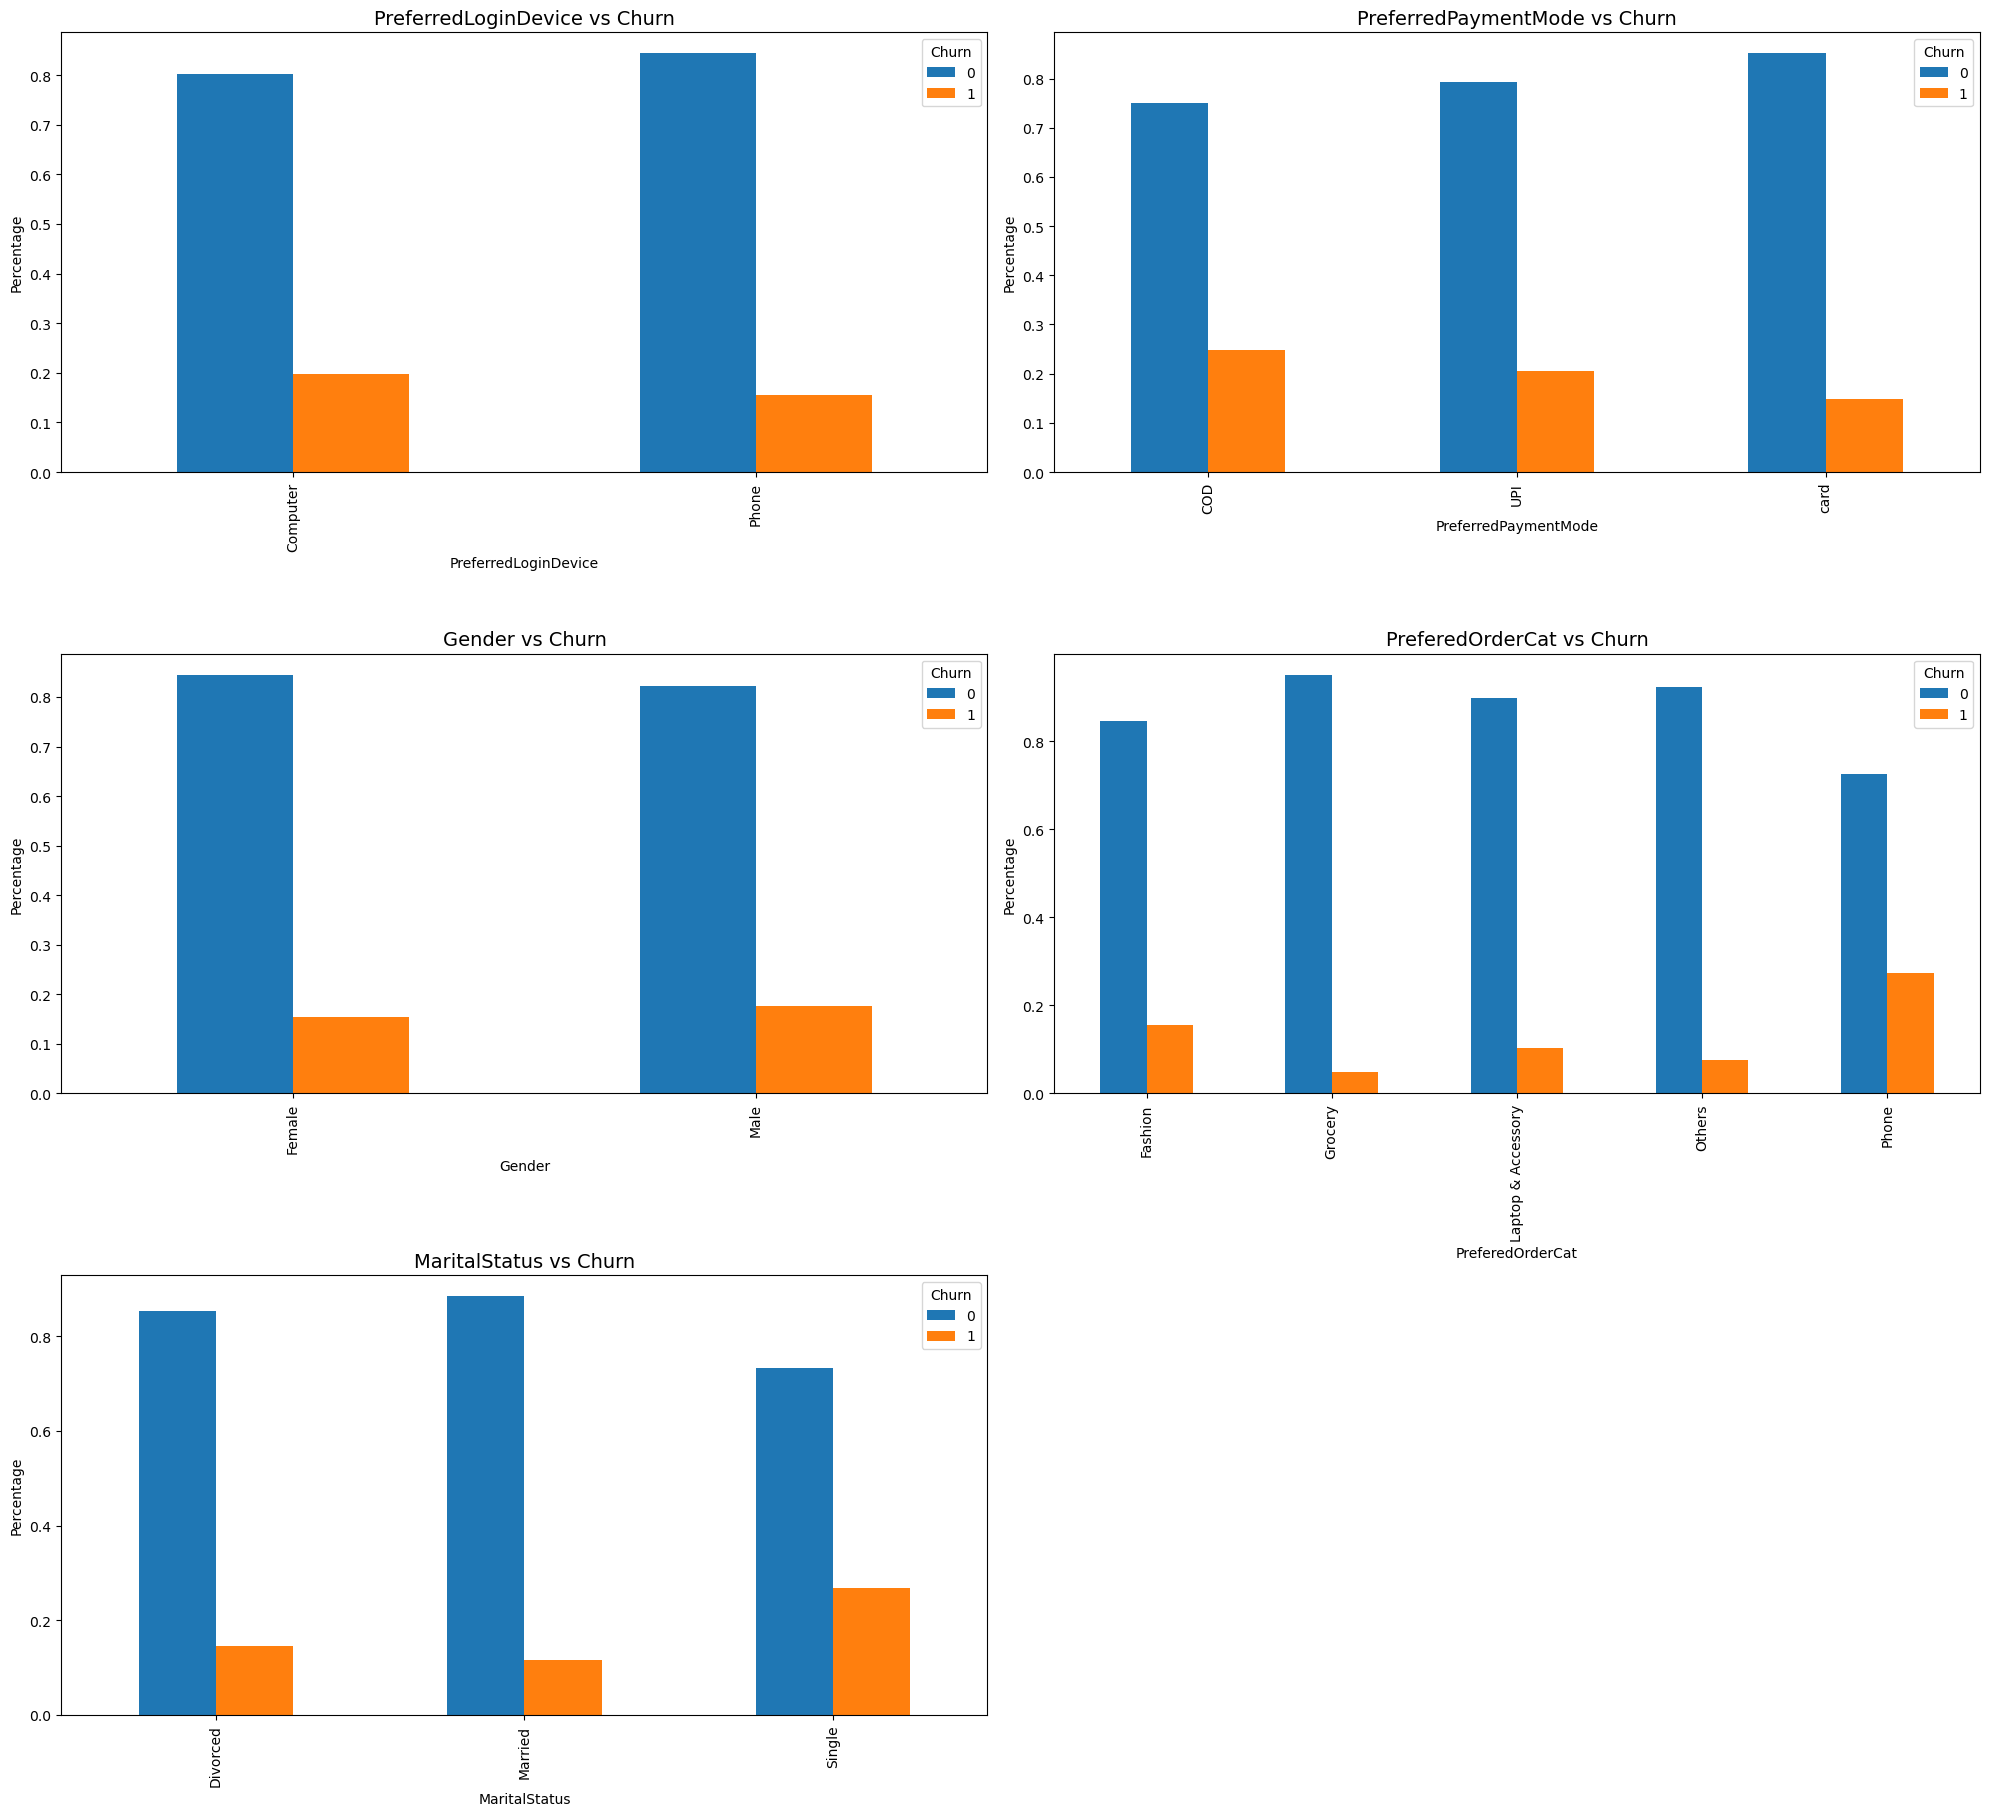

In [338]:
# Filter categorical columns except churn
plot_cols = [col for col in cat_cols if col != 'Churn']

# Define subplot grid
cols = 2
rows = (total_plots + 1)
total_plots = len(plot_cols)

plt.figure(figsize=(20, 6*rows))

for i, col in enumerate(plot_cols):
    dt = pd.crosstab(data[col], data['Churn'], normalize='index')
    
    ax = plt.subplot(rows, cols, i+1)
    dt.plot(kind='bar', ax=ax)
    
    ax.set_title(f"{col} vs Churn", fontsize=14)
    ax.set_xlabel(col)
    ax.set_ylabel("Percentage")

plt.tight_layout()
plt.show()

#### PreferredOrderCategory
##### - Those customers who ordered Phone and all have the higher chances of churn
#### MaritalStatus
##### - Singles are churning more as compared to other categories
#### Gender (NO MAJOR DIFFERENCE)
#### PreferredPaymentMode
##### Cards have least churn and COD have highest. High cost on COD maybe a difference here for high churn

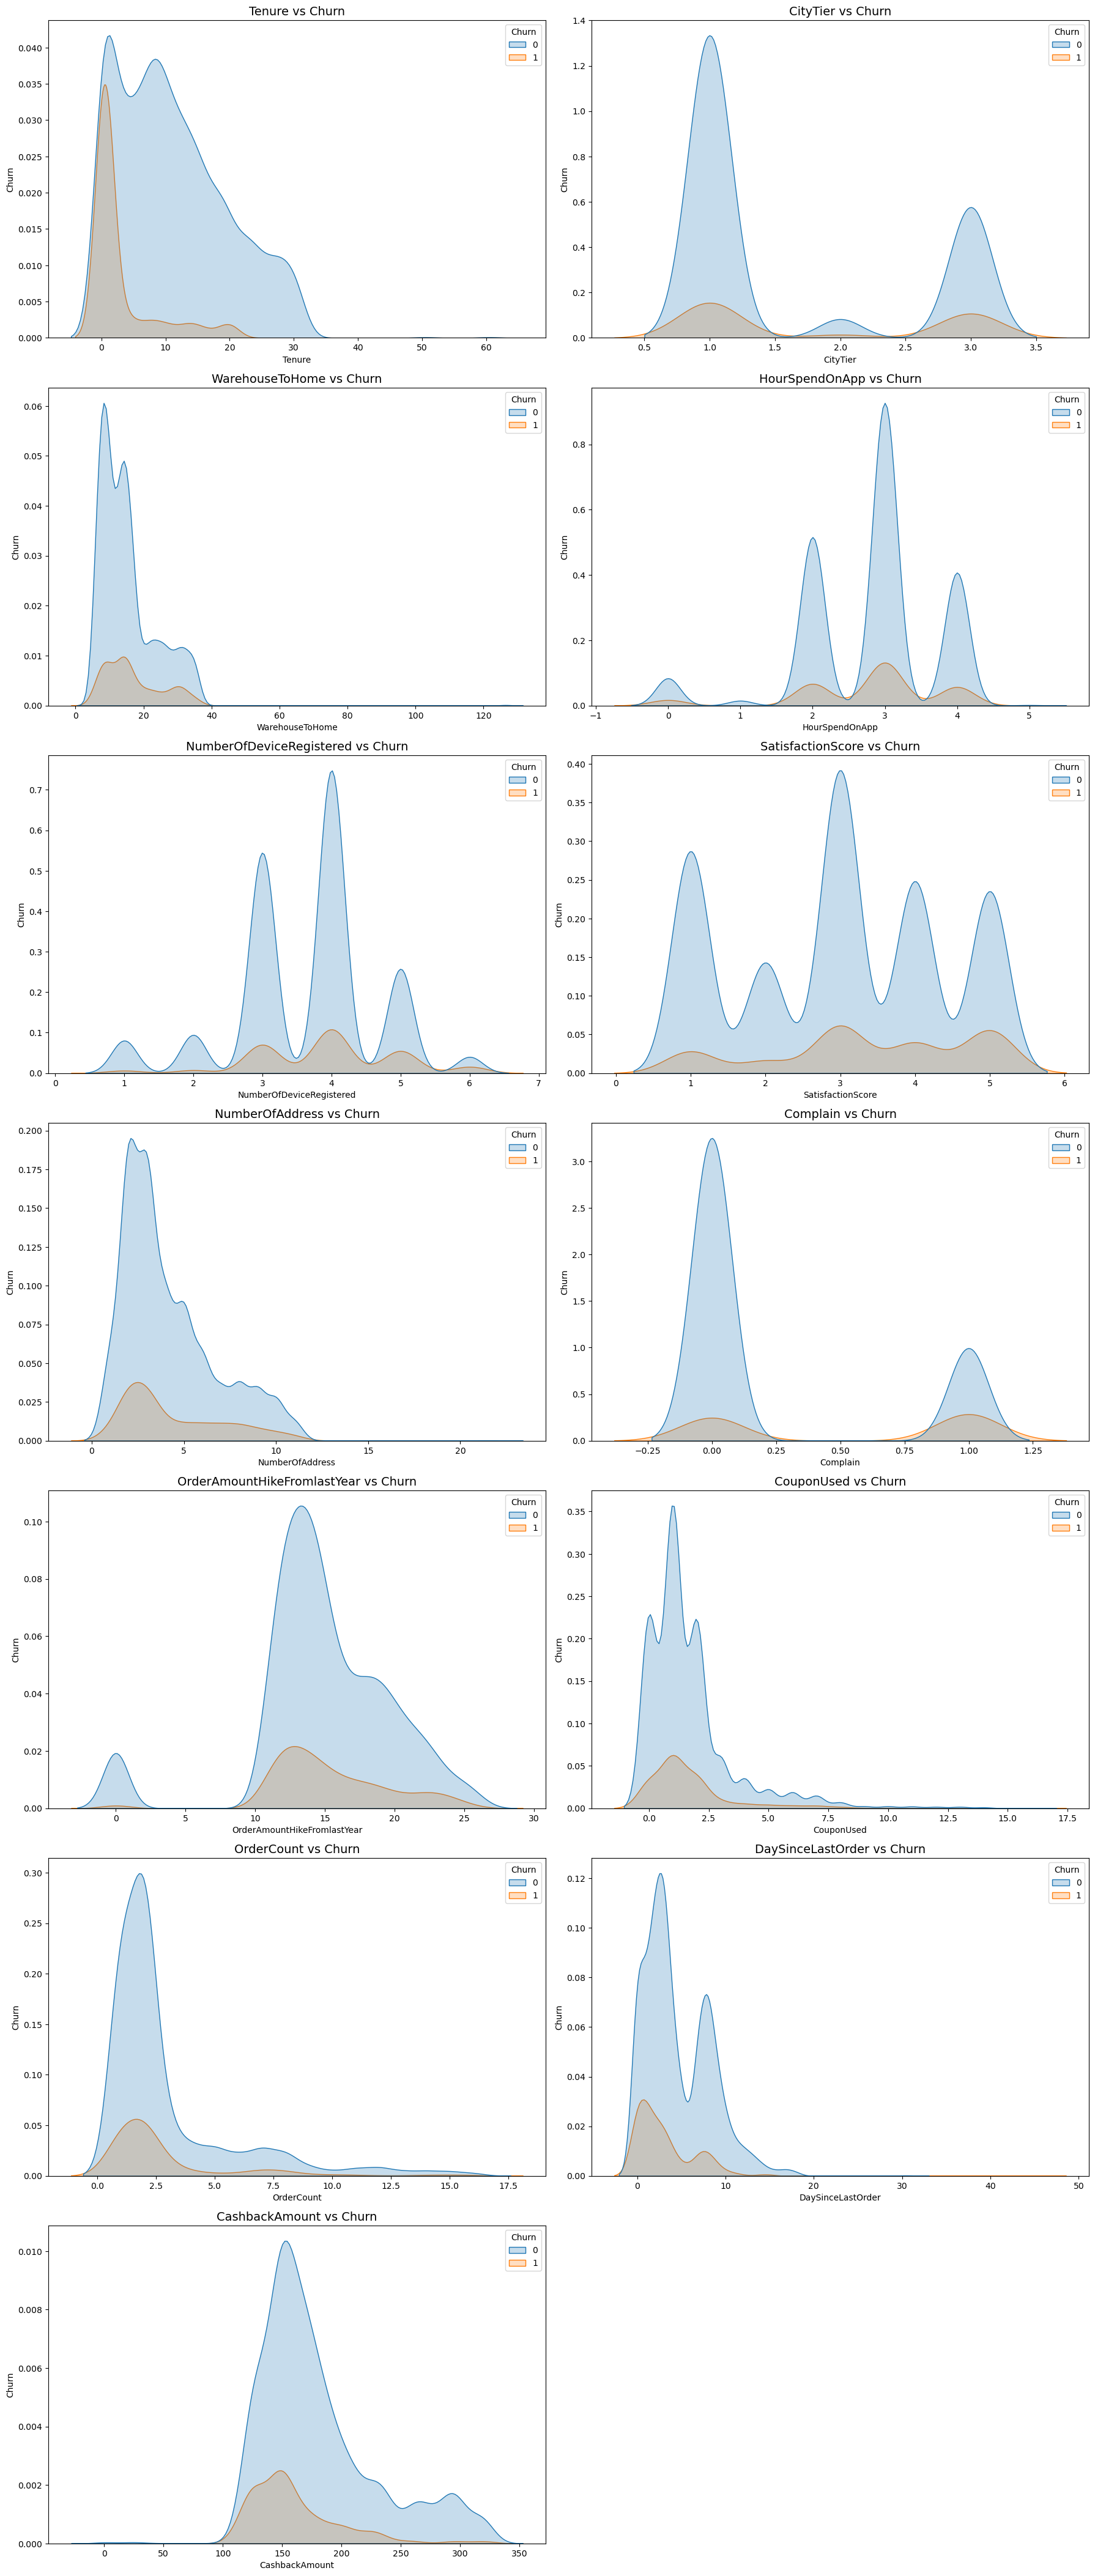

In [238]:
pass_cols = ['CustomerID', 'Churn']
cols = 2
total = len(num_cols)
rows = (total + 1) // cols

plt.figure(figsize=(18, 6 * rows))

for i, col in enumerate(num_cols):
    if col in pass_cols:
        continue
    ax = plt.subplot(rows, cols, i+1)
    sns.kdeplot(data=data, x=col, hue='Churn', fill=True)
    
    ax.set_title(f"{col} vs Churn", fontsize=14)
    ax.set_xlabel(col)
    ax.set_ylabel("Churn")

plt.tight_layout()
plt.show()

#### Tenure
##### - It is left skewed which means customers escape in first 5 months. There maybe any reasons....will find out next
#### CityTier
##### - There is a huge difference between not churning of Tier 1 and Tier 3 cities but only a slight difference between churn rate of both of them, which means churning rate of Tier 3 cities are highest. There may be the reason that customers in Tier-3 cities may experience slower deliveries, which can contribute to possible higher churn
#### Complain
##### - Customers who compaint have higher rate of churn

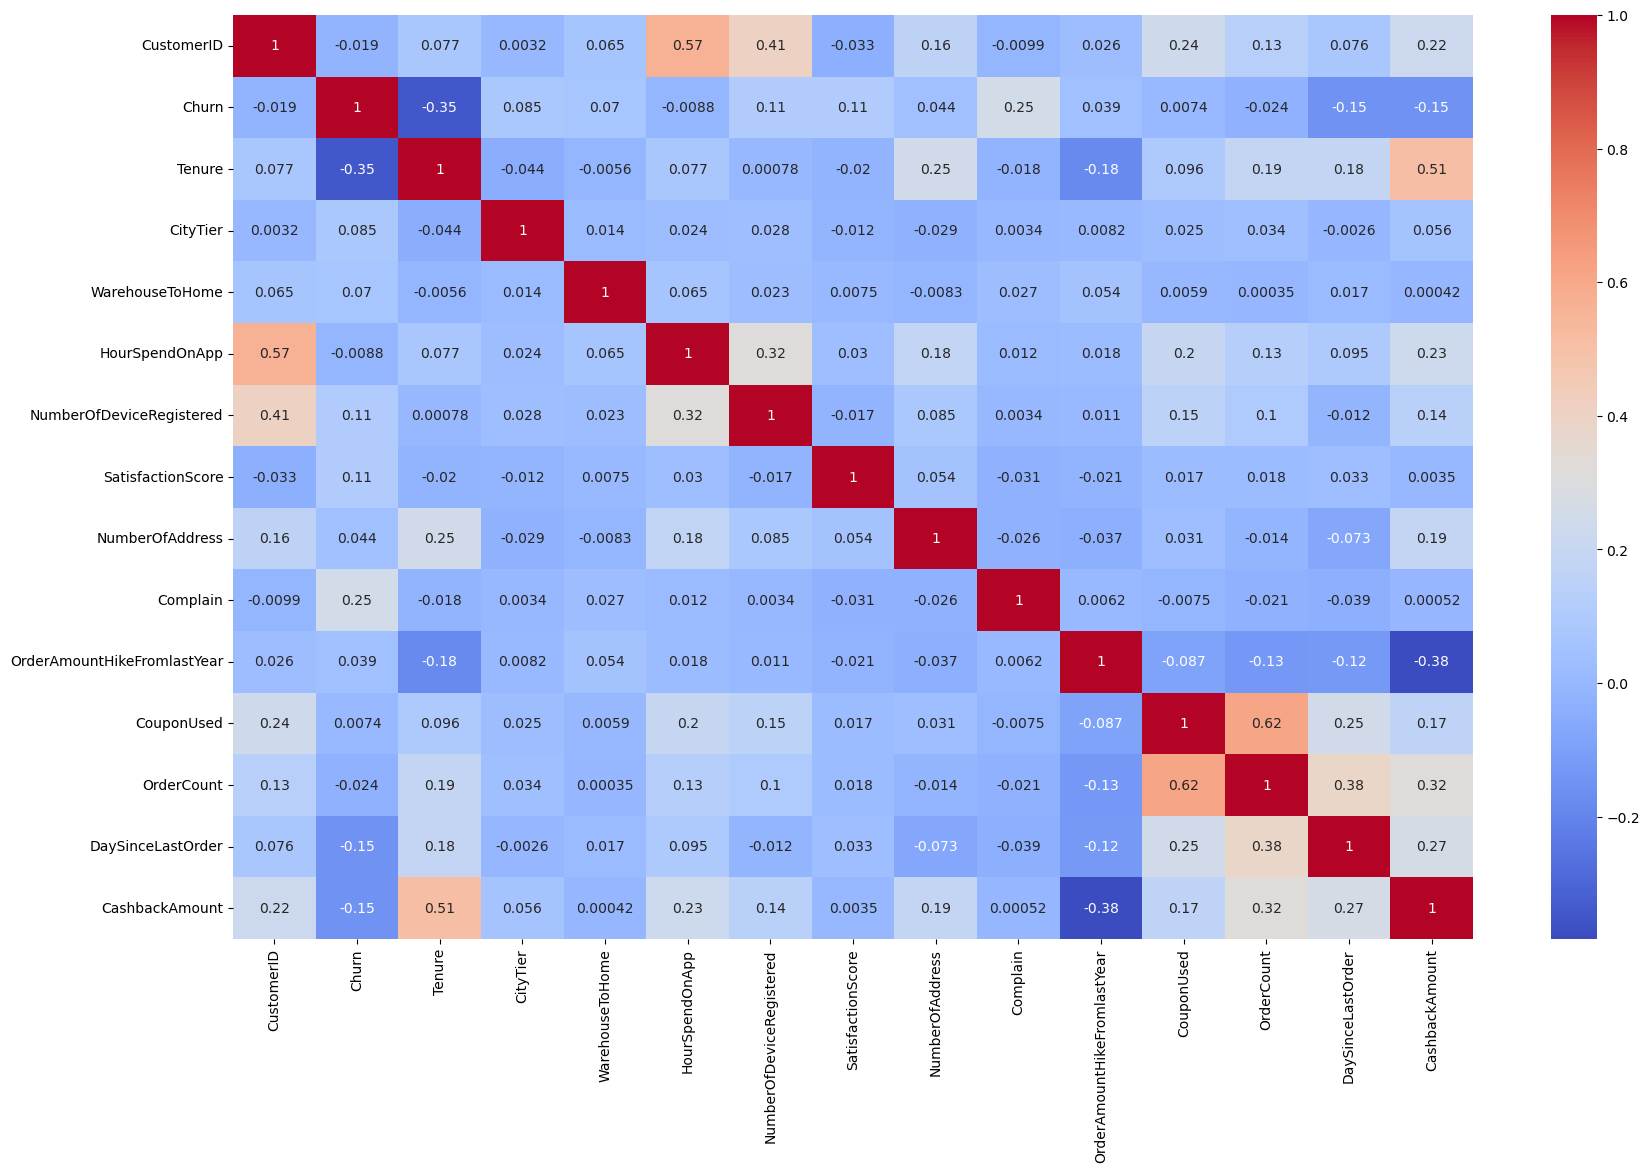

In [258]:
plt.figure(figsize=(20,12))
sns.heatmap(data[num_cols].corr(), annot=True, cmap='coolwarm')
plt.show()

In [272]:
# Compute correlation
corr_matrix = data[num_cols].corr()

# Threshold
threshold = 0.4

# Extract strong correlations
corr_pairs = (
    corr_matrix
        .where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        .stack()
        .reset_index()
)

corr_pairs.columns = ['Feature1', 'Feature2', 'Correlation']

strong_corr = corr_pairs[corr_pairs['Correlation'].abs() > threshold]

print("Highly correlated feature pairs (> 0.4:)")
strong_corr

Highly correlated feature pairs (> 0.4:)


,Feature1,Feature2,Correlation
4,CustomerID,HourSpendOnApp,0.565372
5,CustomerID,NumberOfDeviceRegistered,0.411098
38,Tenure,CashbackAmount,0.509789
99,CouponUsed,OrderCount,0.615498


#### These features are mostly related which means :
##### 1. Tenure of a customer is directly related to cashback amount he will get cashback in the initial phase to stick to the platform
##### 2. Coupon Used is directly related to OrderCount which is quiet obvious, more discount is provided to the customer the more he will spend. Churn rate is also more for that customer who uses more coupons which means they are just using platform for coupons

<Axes: xlabel='OrderCount', ylabel='CouponUsed'>

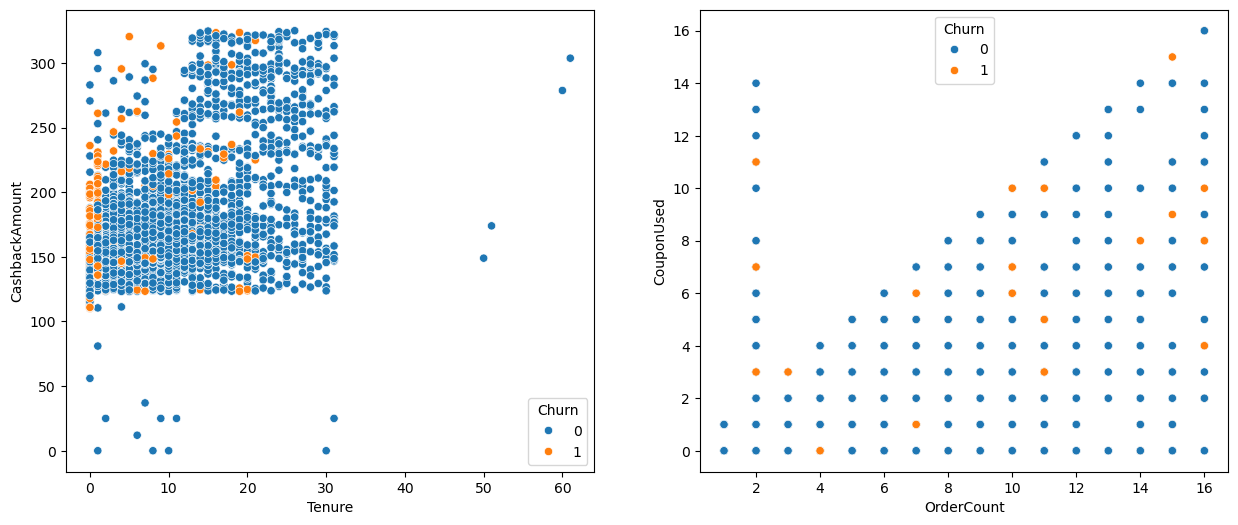

In [291]:
fig, ax= plt.subplots(nrows=1, ncols=2, figsize=(15, 6))

sns.scatterplot(ax = ax[0], x=data['Tenure'], y= data['CashbackAmount'], hue=data['Churn'])
sns.scatterplot(ax = ax[1], y=data['CouponUsed'], x= data['OrderCount'], hue=data['Churn'])

### Extra Analysis

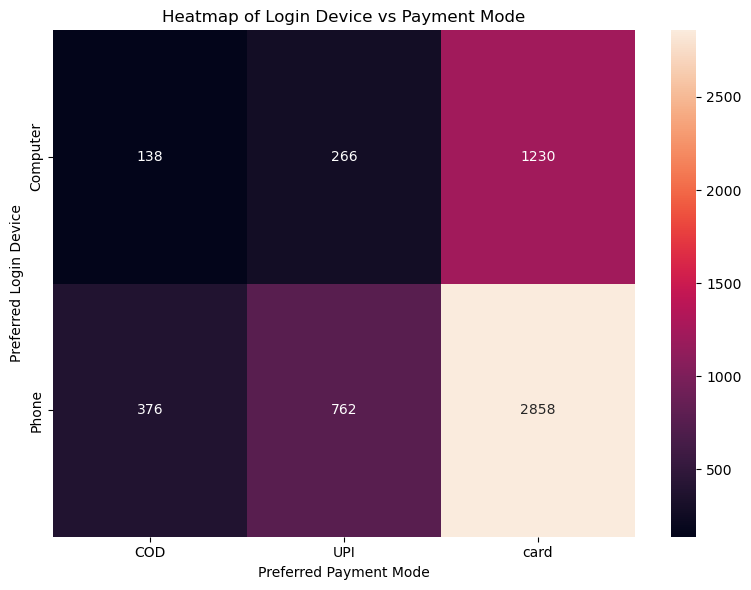

In [339]:
ct = pd.crosstab(data['PreferredLoginDevice'], data['PreferredPaymentMode'])

plt.figure(figsize=(8, 6))
sns.heatmap(ct, annot=True, fmt='d')
plt.title('Heatmap of Login Device vs Payment Mode')
plt.xlabel('Preferred Payment Mode')
plt.ylabel('Preferred Login Device')
plt.tight_layout()
plt.show()


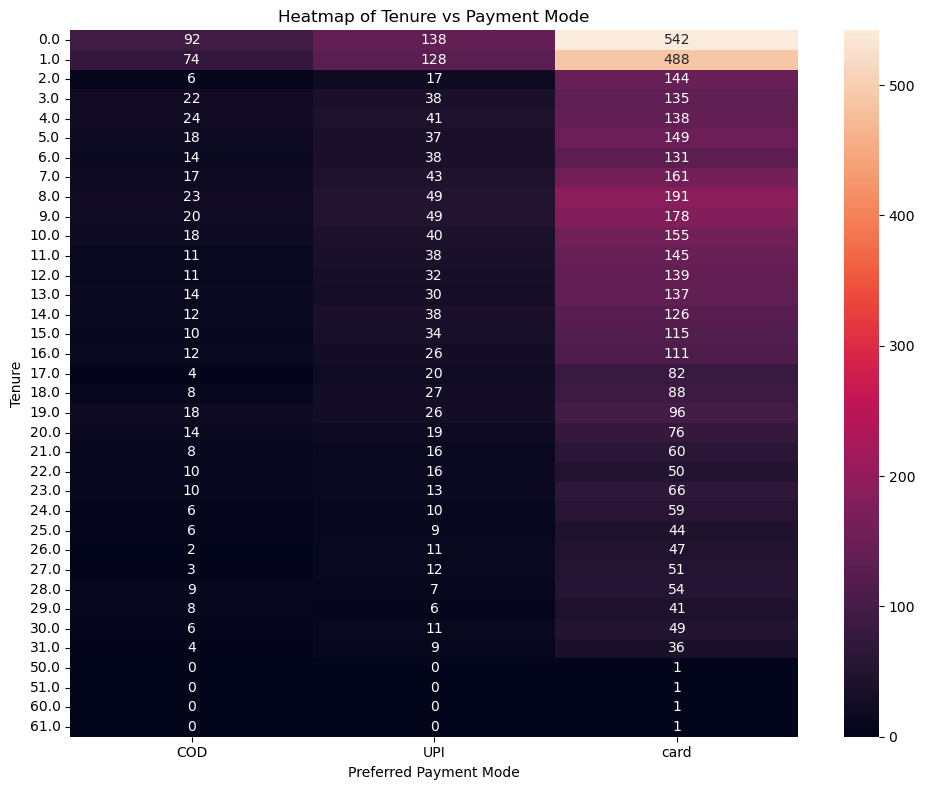

In [344]:
bt = pd.crosstab(data['Tenure'], data['PreferredPaymentMode'])

plt.figure(figsize=(10, 8))
sns.heatmap(bt, annot=True, fmt='d')
plt.title('Heatmap of Tenure vs Payment Mode')
plt.xlabel('Preferred Payment Mode')
plt.ylabel('Tenure')
plt.tight_layout()
plt.show()

## Final Churn Profiles Result

#### **✅ 📌 What Does a Typical Churned Customer Look Like? (Churn = 1)**
Based on our dataset:

*A churned customer tends to be:*

**🔥 1. Very Low Tenure**

Avg tenure: 3.38 months
👉 They are new customers who leave quickly.

**🔥 2. Higher Warehouse-to-Home Distance**

Distance avg: 17.1 km
👉 Farther customers → slower delivery → more churn.

**🔥 3. Slightly Higher App Usage but Still Low**

HourSpendOnApp: 2.96 hrs
👉 No strong effect.

**🔥 4. More Registered Devices**

Devices: 3.93
👉 More devices used but still leaving → probably inconsistent experience.

**🔥 5. Higher Address Change Count**

Address changes: 4.47
👉 More instability → more churn.

**🔥 **6. Much Higher Complaint Rate**

Complaints: 0.53
👉 Churned users complain 2× more.

**🔥 7. Slightly Higher SatisfactionScore (surprising!)**

Satisfaction: 3.39
👉 This dataset’s satisfaction score does not strongly indicate retention.

**🔥 8. Lower Order Count**

Order count: 2.82
👉 Low-engagement customers churn.

**🔥 9. Recently Active Less**

DaysSinceLastOrder: 3.23 days
👉 They left earlier and activity dropped.

**🔥 10. Lower Cashback Received**

Cashback: ₹160.37
👉 Lower incentives → more churn.

### **🟢 SUMMARY: TYPICAL CHURNED CUSTOMER**

***Low tenure + Far from warehouse + More complaints + Fewer orders + Lower cashback received
→ Likely to quit quickly.***

### **✅ 📌 What Does a Typical Non-Churned Customer Look Like? (Churn = 0)**
Based on the data:

**🟩 1. High Tenure / Loyal**

Avg tenure: 11.5 months
👉 Longer-term customers stay.

**🟩 2. Closer to Warehouse**

Warehouse distance: 15.35 km

**🟩 3. Slightly Fewer Devices Registered**

3.63 devices

**🟩 4. Lower Complaints**

Complaints: 0.23
👉 50% fewer complaints than churned customers.

**🟩 5. Similar Satisfaction Score**

Satisfaction: 3.00

**🟩 6. Higher Order Count**

Orders: 3.04

**🟩 7. Higher Cashback**

Cashback: ₹180.63
👉 Cashback is a strong motivator to stay.

**🟩 8. Less frequently active**

Days since last order: 4.8 days
👉 Loyal customers order steadily but not too aggressively.

### **🟢 SUMMARY: TYPICAL NON-CHURNED CUSTOMER**

***High tenure + Fewer complaints + More orders + Close to warehouse + More cashback
→ Highly stable & loyal.***

### **⭐ Business Insights**

*Customers leave primarily because they are:*

* New and not engaged yet (low tenure)

* Receiving poor service (high complaints)

* Experiencing delays (longer distance)

Now will do Preprocessing on this data

In [29]:
data.to_csv('E_Comm_cleaned.csv', index=False)